<a href="https://colab.research.google.com/github/Rxjxt/machine-learning-lab-/blob/main/lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
from google.colab import files
uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020.csv


In [6]:
import pandas as pd

df = pd.read_csv("ai4i2020.csv")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
print(df.info())
print(df.describe())
print("Missing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [8]:
target_col = 'Machine failure'

print(df[target_col].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


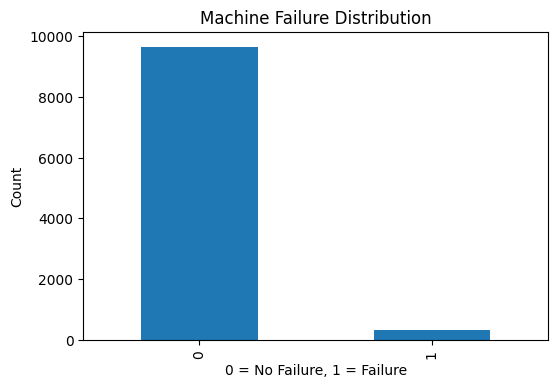

In [9]:
plt.figure(figsize=(6,4))

df[target_col].value_counts().plot(kind='bar')

plt.title('Machine Failure Distribution')
plt.xlabel('0 = No Failure, 1 = Failure')
plt.ylabel('Count')

plt.show()

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
for col in df.columns:
    print(f"'{col}'")

'UDI'
'Air temperature [K]'
'Process temperature [K]'
'Rotational speed [rpm]'
'Torque [Nm]'
'Tool wear [min]'
'Machine failure'
'TWF'
'HDF'
'PWF'
'OSF'
'RNF'
'Product ID_H29425'
'Product ID_H29432'
'Product ID_H29434'
'Product ID_H29441'
'Product ID_H29452'
'Product ID_H29457'
'Product ID_H29462'
'Product ID_H29466'
'Product ID_H29481'
'Product ID_H29494'
'Product ID_H29500'
'Product ID_H29522'
'Product ID_H29525'
'Product ID_H29550'
'Product ID_H29552'
'Product ID_H29557'
'Product ID_H29560'
'Product ID_H29569'
'Product ID_H29571'
'Product ID_H29580'
'Product ID_H29581'
'Product ID_H29595'
'Product ID_H29606'
'Product ID_H29607'
'Product ID_H29610'
'Product ID_H29626'
'Product ID_H29635'
'Product ID_H29680'
'Product ID_H29682'
'Product ID_H29684'
'Product ID_H29691'
'Product ID_H29702'
'Product ID_H29707'
'Product ID_H29712'
'Product ID_H29716'
'Product ID_H29724'
'Product ID_H29734'
'Product ID_H29742'
'Product ID_H29743'
'Product ID_H29764'
'Product ID_H29767'
'Product ID_H29776'
'

In [14]:
df.columns = df.columns.str.strip()

# ❗ sirf UDI drop karo
df = df.drop(['UDI'], axis=1)

In [15]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [16]:
# encoding already ho chuka hai (Product ID columns ban gaye hain)
# agar Type abhi bhi hai to:
df = pd.get_dummies(df, drop_first=True)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
predictions = rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))

[[2886    0]
 [   6  108]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2886
           1       1.00      0.95      0.97       114

    accuracy                           1.00      3000
   macro avg       1.00      0.97      0.99      3000
weighted avg       1.00      1.00      1.00      3000

Accuracy: 0.998


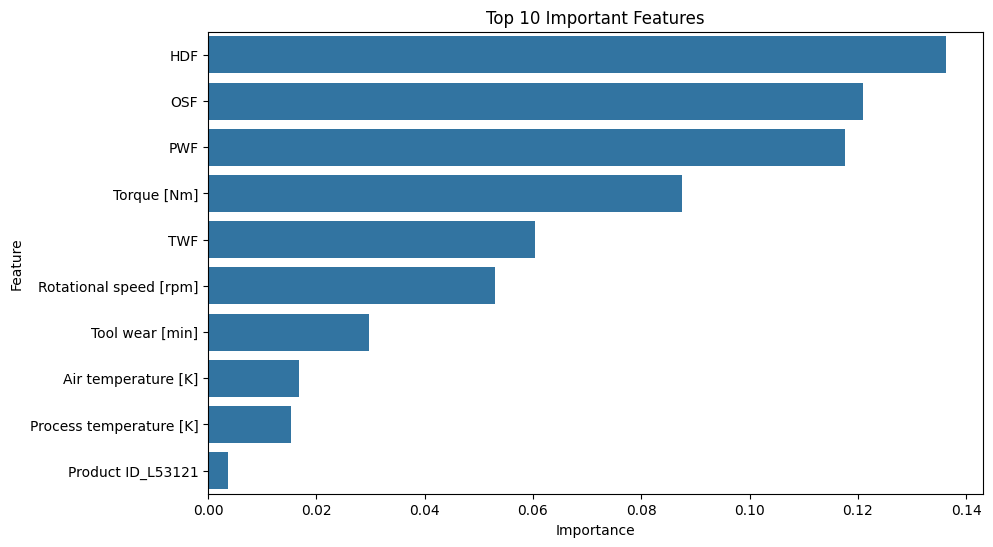

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))

plt.title('Top 10 Important Features')
plt.show()